# The 34% Error — Notebook

Three charts for the final piece, in order of appearance.

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('data/merged_df.csv', dtype={'fips': str})
df['log_pop_density'] = np.log10(df['pop_density'])
df = df.dropna(
    subset=['life_expectancy', 'median_hh_income', 'pct_bachelors_plus',
            'pct_poverty', 'pct_native_american', 'median_age', 'log_pop_density']
)

# Model without pct_native_american — residuals show gap beyond SES
controls = ['median_hh_income', 'pct_bachelors_plus', 'pct_poverty',
            'median_age', 'log_pop_density']
m = sm.OLS(df['life_expectancy'], sm.add_constant(df[controls])).fit()
df['resid']     = m.resid
df['predicted'] = m.fittedvalues
df['gap']       = df['life_expectancy'] - df['predicted']
df['high_na']   = df['pct_native_american'] > 20

print(f"n = {len(df):,} counties")
print(f"Model R² (without Native American share): {m.rsquared:.3f}")


n = 3,062 counties
Model R² (without Native American share): 0.613


## Chart 1 — Residuals scatter
*"Even controlling for socioeconomics, Native American counties fall short in life expectancy"*

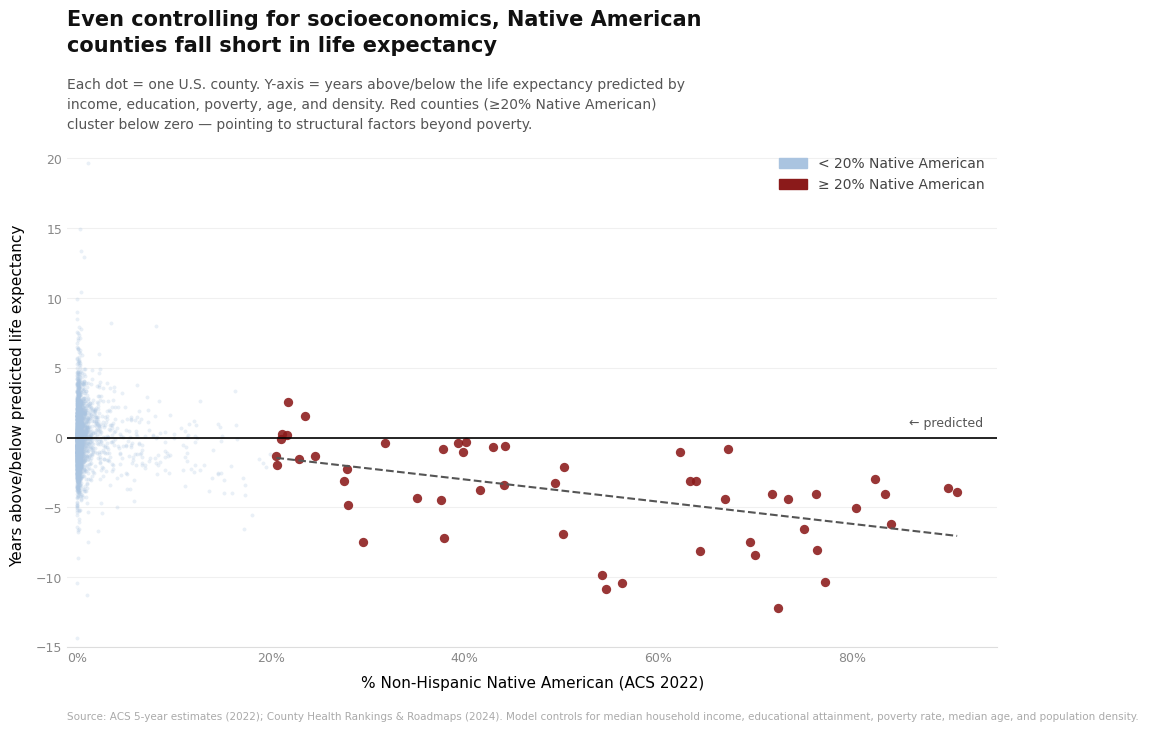

In [14]:
# Trend line through high-NA counties
high = df[df['high_na']]
m2 = sm.OLS(high['resid'], sm.add_constant(high['pct_native_american'])).fit()
x_line = np.linspace(high['pct_native_american'].min(), high['pct_native_american'].max(), 200)
y_line = m2.params['const'] + m2.params['pct_native_american'] * x_line

BG = '#ffffff'
fig, ax = plt.subplots(figsize=(12, 7.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(top=0.78)

low = df[~df['high_na']]
ax.scatter(low['pct_native_american'], low['resid'],
           s=8, color='#aac4e0', alpha=0.25, linewidths=0, zorder=2)
ax.scatter(high['pct_native_american'], high['resid'],
           s=45, color='#8B1A1A', alpha=0.88, linewidths=0, zorder=3)

ax.plot(x_line, y_line, color='#555', linestyle='--', linewidth=1.5, zorder=4)
ax.axhline(0, color='black', linewidth=1.2, zorder=4)
ax.text(93.5, 0.6, '← predicted', fontsize=9, color='#555', ha='right', va='bottom')

ax.set_xlabel('% Non-Hispanic Native American (ACS 2022)', fontsize=11, labelpad=8)
ax.set_ylabel('Years above/below predicted life expectancy', fontsize=11, labelpad=8)
ax.set_ylim(-15, 21)
ax.set_xlim(-1, 95)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.tick_params(axis='both', length=0)
ax.yaxis.set_tick_params(labelsize=9, labelcolor='#888')
ax.xaxis.set_tick_params(labelsize=9, labelcolor='#888')
ax.grid(axis='y', color='#f0f0f0', linewidth=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#ddd')

ax.legend(handles=[
    mpatches.Patch(color='#aac4e0', label='< 20% Native American'),
    mpatches.Patch(color='#8B1A1A', label='≥ 20% Native American'),
], loc='upper right', fontsize=10, frameon=False, labelcolor='#444')

fig.text(0.125, 0.96,
         'Even controlling for socioeconomics, Native American\ncounties fall short in life expectancy',
         fontsize=15, fontweight='bold', va='top', ha='left', color='#111', linespacing=1.4)
fig.text(0.125, 0.87,
         'Each dot = one U.S. county. Y-axis = years above/below the life expectancy predicted by\n'
         'income, education, poverty, age, and density. Red counties (≥20% Native American)\n'
         'cluster below zero — pointing to structural factors beyond poverty.',
         fontsize=10, color='#555', va='top', ha='left', linespacing=1.55)
fig.text(0.125, 0.01,
         'Source: ACS 5-year estimates (2022); County Health Rankings & Roadmaps (2024). '
         'Model controls for median household income, educational attainment, poverty rate, median age, and population density.',
         fontsize=7.5, color='#aaa', va='bottom')

plt.savefig('Resid-Visual2-final.svg', format='svg', bbox_inches='tight', facecolor=BG)
plt.savefig('Resid-Visual2-final.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()


## Chart 2 — Dumbbell

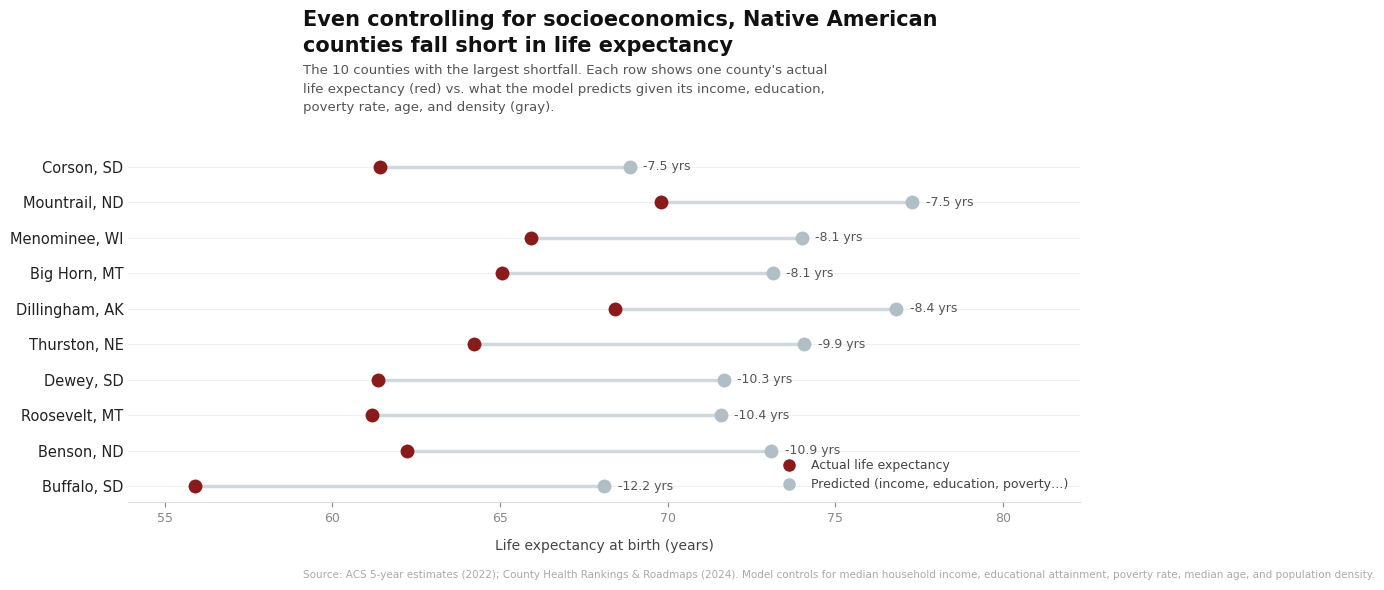

In [15]:
import matplotlib.lines as mlines

STATE_ABBR = {
    'South Dakota': 'SD', 'North Dakota': 'ND', 'Montana': 'MT',
    'Alaska': 'AK', 'Nebraska': 'NE', 'Wisconsin': 'WI',
    'Minnesota': 'MN', 'New Mexico': 'NM', 'Arizona': 'AZ',
    'Wyoming': 'WY', 'Oklahoma': 'OK', 'Michigan': 'MI',
}
plot_df = (df[df['pct_native_american'] > 20]
           .nsmallest(10, 'gap')
           .copy())
plot_df['label'] = (
    plot_df['county_name']
    .str.replace(' County', '').str.replace(' Census Area', '').str.replace(' Borough', '')
    + ', ' + plot_df['state_name'].map(STATE_ABBR).fillna(plot_df['state_name'].str[:2])
)
plot_df = plot_df.sort_values('gap', ascending=True)

ACTUAL_COLOR    = '#8B1A1A'
PREDICTED_COLOR = '#b0bec5'
LINE_COLOR      = '#cfd8dc'
BG              = '#ffffff'

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(left=0.28, right=0.88, top=0.75, bottom=0.1)

y_pos = np.arange(len(plot_df))
for y in y_pos:
    ax.axhline(y, color='#f0f0f0', linewidth=0.8, zorder=1)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['life_expectancy'], row['predicted']], [i, i],
            color=LINE_COLOR, linewidth=2.5, solid_capstyle='round', zorder=2)

ax.scatter(plot_df['predicted'],       y_pos, color=PREDICTED_COLOR, s=100, zorder=3, linewidths=0)
ax.scatter(plot_df['life_expectancy'], y_pos, color=ACTUAL_COLOR,    s=100, zorder=4, linewidths=0)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(max(row['life_expectancy'], row['predicted']) + 0.4, i,
            f'{row["gap"]:+.1f} yrs', va='center', ha='left',
            fontsize=9, color='#555', fontfamily='sans-serif')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['label'], fontsize=10.5, fontfamily='sans-serif', color='#222')
ax.set_xlabel('Life expectancy at birth (years)', fontsize=10, color='#444', labelpad=10)
ax.tick_params(axis='x', colors='#888', labelsize=9)
ax.tick_params(axis='y', length=0)
ax.set_xlim(plot_df[['life_expectancy','predicted']].min().min() - 2,
            plot_df[['life_expectancy','predicted']].max().max() + 5)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#ddd')

fig.text(0.28, 0.96,
         'Even controlling for socioeconomics, Native American\ncounties fall short in life expectancy',
         fontsize=15, fontweight='bold', va='top', ha='left', color='#111', linespacing=1.4)
fig.text(0.28, 0.87,
         "The 10 counties with the largest shortfall. Each row shows one county's actual\n"
         'life expectancy (red) vs. what the model predicts given its income, education,\n'
         'poverty rate, age, and density (gray).',
         fontsize=9.5, color='#555', va='top', ha='left', linespacing=1.55)

leg_actual    = mlines.Line2D([], [], color=ACTUAL_COLOR,    marker='o', markersize=8,
                               linestyle='None', label='Actual life expectancy')
leg_predicted = mlines.Line2D([], [], color=PREDICTED_COLOR, marker='o', markersize=8,
                               linestyle='None', label='Predicted (income, education, poverty…)')
ax.legend(handles=[leg_actual, leg_predicted], loc='lower right', frameon=False,
          fontsize=9, labelcolor='#444')

fig.text(0.28, 0.01,
         'Source: ACS 5-year estimates (2022); County Health Rankings & Roadmaps (2024). '
         'Model controls for median household income, educational attainment, poverty rate, median age, and population density.',
         fontsize=7.5, color='#aaa', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.75])
plt.savefig('dumbbell.svg', format='svg', bbox_inches='tight', facecolor=BG)
plt.savefig('dumbbell.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()


## Chart 3 — COVID timeline
*"AIAN life expectancy crashed during COVID — and hasn't fully recovered"*

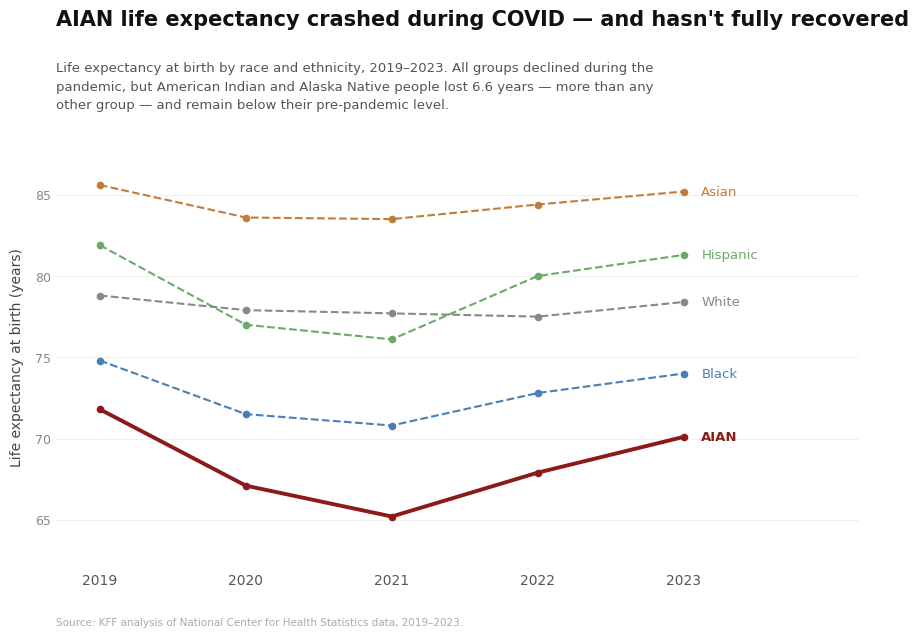

In [16]:
trend_data = [
    {'year': 2019, 'group': 'AIAN',     'le': 71.8},
    {'year': 2020, 'group': 'AIAN',     'le': 67.1},
    {'year': 2021, 'group': 'AIAN',     'le': 65.2},
    {'year': 2022, 'group': 'AIAN',     'le': 67.9},
    {'year': 2023, 'group': 'AIAN',     'le': 70.1},
    {'year': 2019, 'group': 'White',    'le': 78.8},
    {'year': 2020, 'group': 'White',    'le': 77.9},
    {'year': 2021, 'group': 'White',    'le': 77.7},
    {'year': 2022, 'group': 'White',    'le': 77.5},
    {'year': 2023, 'group': 'White',    'le': 78.4},
    {'year': 2019, 'group': 'Black',    'le': 74.8},
    {'year': 2020, 'group': 'Black',    'le': 71.5},
    {'year': 2021, 'group': 'Black',    'le': 70.8},
    {'year': 2022, 'group': 'Black',    'le': 72.8},
    {'year': 2023, 'group': 'Black',    'le': 74.0},
    {'year': 2019, 'group': 'Hispanic', 'le': 81.9},
    {'year': 2020, 'group': 'Hispanic', 'le': 77.0},
    {'year': 2021, 'group': 'Hispanic', 'le': 76.1},
    {'year': 2022, 'group': 'Hispanic', 'le': 80.0},
    {'year': 2023, 'group': 'Hispanic', 'le': 81.3},
    {'year': 2019, 'group': 'Asian',    'le': 85.6},
    {'year': 2020, 'group': 'Asian',    'le': 83.6},
    {'year': 2021, 'group': 'Asian',    'le': 83.5},
    {'year': 2022, 'group': 'Asian',    'le': 84.4},
    {'year': 2023, 'group': 'Asian',    'le': 85.2},
]
trend_df = pd.DataFrame(trend_data)

COLORS     = {'AIAN': '#8B1A1A', 'White': '#888888', 'Black': '#4a7fb5',
              'Hispanic': '#6aaa6a', 'Asian': '#c07d3a'}
LINEWIDTHS = {'AIAN': 2.8, 'White': 1.5, 'Black': 1.5, 'Hispanic': 1.5, 'Asian': 1.5}
LINESTYLES = {'AIAN': '-',  'White': '--', 'Black': '--', 'Hispanic': '--', 'Asian': '--'}

BG = '#ffffff'
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(left=0.09, right=0.82, top=0.75, bottom=0.1)

for group, gdf in trend_df.groupby('group'):
    gdf = gdf.sort_values('year')
    ax.plot(gdf['year'], gdf['le'],
            color=COLORS[group], linewidth=LINEWIDTHS[group], linestyle=LINESTYLES[group],
            marker='o', markersize=5.5, markerfacecolor=COLORS[group], markeredgewidth=0,
            zorder=4 if group == 'AIAN' else 3)
    last = gdf[gdf['year'] == 2023].iloc[0]
    ax.text(2023.12, last['le'], group, va='center', ha='left', fontsize=9.5,
            color=COLORS[group], fontweight='bold' if group == 'AIAN' else 'normal')

ax.set_xticks([2019, 2020, 2021, 2022, 2023])
ax.set_xticklabels(['2019','2020','2021','2022','2023'], fontsize=10, color='#555')
ax.set_ylabel('Life expectancy at birth (years)', fontsize=10, color='#444', labelpad=8)
ax.set_ylim(62, 88)
ax.set_xlim(2018.7, 2024.2)
ax.tick_params(axis='both', length=0)
ax.yaxis.set_tick_params(labelsize=9, labelcolor='#888')
ax.grid(axis='y', color='#f0f0f0', linewidth=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.09, 0.96,
         "AIAN life expectancy crashed during COVID — and hasn't fully recovered",
         fontsize=15, fontweight='bold', va='top', ha='left', color='#111')
fig.text(0.09, 0.88,
         'Life expectancy at birth by race and ethnicity, 2019–2023. All groups declined during the\n'
         'pandemic, but American Indian and Alaska Native people lost 6.6 years — more than any\n'
         'other group — and remain below their pre-pandemic level.',
         fontsize=9.5, color='#555', va='top', ha='left', linespacing=1.55)
fig.text(0.09, 0.01,
         'Source: KFF analysis of National Center for Health Statistics data, 2019–2023.',
         fontsize=7.5, color='#aaa', va='bottom')

plt.savefig('covid-timeline.svg', format='svg', bbox_inches='tight', facecolor=BG)
plt.savefig('covid-timeline.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
